In [72]:
# ==============================
# Student Dropout Prediction with Logistic Regression
# ==============================

# 📌 Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import pickle


In [73]:
# 📌 Cell 2: Load the dataset
df = pd.read_csv("DATA/dataset.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [74]:
# =============================================
# Cell 3: Select Important Features
# (Only from the screenshot you shared)
# =============================================
selected_features = [
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Gender",
    "Educational special needs",
    "Course"
]

X = df[selected_features]
# Convert target to binary: 1 = Dropout, 0 = Not Dropout
y = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)


print("Features selected:", X.columns.tolist())


Features selected: ['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', 'Curricular units 1st sem (grade)', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Gender', 'Educational special needs', 'Course']


In [75]:
# =============================================
# Cell 4: Encode Categorical Columns
# =============================================
label_encoders = {}
categorical_cols = ["Gender", "Course"]

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("Categorical columns encoded:", categorical_cols)


Categorical columns encoded: ['Gender', 'Course']


/tmp/ipykernel_5621/3376721212.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_5621/3376721212.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


In [76]:
# =============================================
# Cell 5: Train-Test Split & Scaling
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [77]:
# =============================================
# Cell 6: Train Logistic Regression Model
# =============================================
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📌 Classification Report:\n", classification_report(y_test, y_pred))


✅ Accuracy: 0.8757062146892656

📌 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91       601
           1       0.86      0.73      0.79       284

    accuracy                           0.88       885
   macro avg       0.87      0.84      0.85       885
weighted avg       0.87      0.88      0.87       885



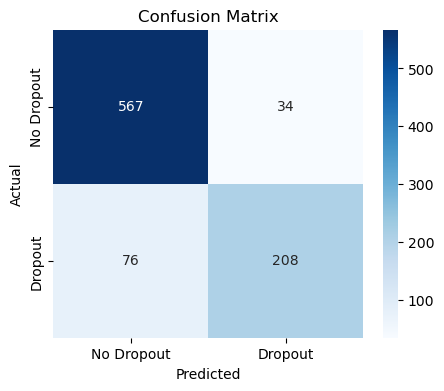

In [78]:
# =============================================
# Cell 7: Confusion Matrix
# =============================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Dropout","Dropout"],
            yticklabels=["No Dropout","Dropout"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [84]:
# =============================================
# Cell 6C: Random Forest Classifier
# =============================================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)  # no scaling needed for trees

rf_pred = rf_model.predict(X_test)

print("🌳 Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\n📌 Classification Report (RF):\n", classification_report(y_test, rf_pred))

#  --- Confusion Matrix for Random Forest ---
cm_rf = confusion_matrix(y_test, rf_pred)
print(cm_rf)

🌳 Random Forest Accuracy: 0.8610169491525423

📌 Classification Report (RF):
               precision    recall  f1-score   support

           0       0.87      0.94      0.90       601
           1       0.84      0.70      0.76       284

    accuracy                           0.86       885
   macro avg       0.86      0.82      0.83       885
weighted avg       0.86      0.86      0.86       885

[[564  37]
 [ 86 198]]


In [83]:
# =============================================
# Cell 6D: XGBoost Classifier (Multiclass Fix)
# =============================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="multi:softmax",   # ✅ multiclass mode
    num_class=3,                 # ✅ since we have 3 classes
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("⚡ XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\n📌 Classification Report (XGBoost):\n", classification_report(y_test, xgb_pred))

cm_xgb = confusion_matrix(y_test, xgb_pred)
print(cm_xgb)


⚡ XGBoost Accuracy: 0.8531073446327684

📌 Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.87      0.92      0.89       601
           1       0.81      0.71      0.76       284

    accuracy                           0.85       885
   macro avg       0.84      0.81      0.83       885
weighted avg       0.85      0.85      0.85       885

[[554  47]
 [ 83 201]]


In [ ]:
# =============================================
# Cell 8: Save Model & Scaler
# =============================================
with open("log_reg_model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("✅ Model, Scaler, and Encoders saved successfully!")


✅ Model, Scaler, and Encoders saved successfully!


In [ ]:
# =============================================
# Cell 9 (Fixed Properly): Example Prediction
# =============================================
# IMPORTANT: Use numeric codes (0/1) since encoder classes are [0,1]

new_student = {
    "Curricular units 1st sem (approved)": 4,
    "Curricular units 2nd sem (approved)": 3,
    "Curricular units 1st sem (grade)": 10.5,
    "Debtor": 1,
    "Tuition fees up to date": 0,
    "Scholarship holder": 0,
    "Gender": 1,   # ✅ numeric, not string
    "Educational special needs": 0,
    "Course": 6   # ✅ also numeric, must match what encoder saw
}

new_df = pd.DataFrame([new_student])

# Skip encoding step because values are already numeric
new_df = new_df[selected_features]

# Scale
new_df_scaled = scaler.transform(new_df)

# Predict
prediction = log_reg.predict(new_df_scaled)[0]

print("🎯 Predicted Dropout Status:", "Dropout" if prediction == 1 else "No Dropout")


1
🎯 Predicted Dropout Status: Dropout
